In this notebook, we test our method on a simple RNN and letter sequences. You can find a description of the experiment in section 4.3 of our article.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
from Meta_learning import MetaLearner
import Meta_loss_functions as mlf

In [4]:
class Generator(nn.Module):
    def __init__(self, num_classes, n_per_class, seq_len, vocab_size=5):
        super().__init__()
        self.num_classes = num_classes
        self.n_per_class = n_per_class
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.total = num_classes * n_per_class
        
        init_data = torch.rand(self.total, seq_len, vocab_size)
        init_data = init_data / init_data.sum(dim=-1, keepdim=True)
        self.data = nn.Parameter(init_data)
    
    def forward(self, z=None, y=None):
        x = F.softmax(self.data, dim=-1)
        return x
    
    def visualize(self, x=None, y=None, n_visualize=20, save_path=None):
        if x is None or y is None:
            x, y = self.generate_dataset()

        indices = x.argmax(dim=-1).detach().cpu().numpy()
        y = y.detach().cpu().numpy()

        letters = [chr(ord('A') + i) for i in range(self.vocab_size)]
        
        n_visualize = min(n_visualize, self.n_per_class)

        n_subcols = 4
        n_rows_per_subcol = 5
        
        num_cols = self.num_classes
        
        fig_height = n_rows_per_subcol * 0.4 + 0.5
        
        fig, axes = plt.subplots(1, num_cols, figsize=(num_cols * 3.2, fig_height))
        
        if num_cols == 1:
            axes = [axes]
    
        for class_idx in range(self.num_classes):
            ax = axes[class_idx]
            ax.axis('off')
            ax.set_title(f'Class {class_idx}', fontsize=11, fontweight='bold')
            
            class_indices = np.where(y == class_idx)[0][:n_visualize]
            
            if len(class_indices) == 0:
                ax.text(0.5, 0.5, 'No samples', ha='center', va='center', fontsize=10)
                continue

            subcol_width = 0.9 / n_subcols
            subcol_start_x = 0.05
            
            for subcol in range(n_subcols):
                start_idx = subcol * n_rows_per_subcol
                end_idx = min(start_idx + n_rows_per_subcol, len(class_indices))
                
                if start_idx >= len(class_indices):
                    continue

                subcol_x = subcol_start_x + (subcol + 0.5) * subcol_width
                
                step_y = 0.85 / n_rows_per_subcol
                start_y = 0.9
                
                for i, offset in enumerate(range(start_idx, end_idx)):
                    idx = class_indices[offset]
                    seq = indices[idx]
                    seq_str = ''.join([letters[c] for c in seq])
                    
                    y_pos = start_y - i * step_y
                    
                    bg_color = '#f0f0f0' if i % 2 == 0 else 'white'
                    
                    ax.text(subcol_x, y_pos, seq_str, fontsize=8, family='monospace',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round', facecolor=bg_color, edgecolor='gray', linewidth=0.3, pad=0.5))
            
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', linewidth=1))
        
        plt.tight_layout()
        
        plt.show()

In [5]:
class RNN(nn.Module):
    def __init__(self, num_classes, vocab_size=5, hidden_dim=32, num_layers=2):
        super().__init__()
        
        self.rnn = nn.RNN(
            input_size=vocab_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        last_out = out[:, -1, :]
        return self.fc(last_out)

In [6]:
def regularizer_combined(generator, x, y, reg_lambda=0.05, lambda_distance=0.2, lambda_position=0.8):
    num_classes = len(torch.unique(y))
    seq_len = x.shape[1]
    vocab_size = x.shape[2]

    x_flat = x.view(x.size(0), -1)
    x_flat = x_flat / (x_flat.norm(dim=1, keepdim=True) + 1e-8)
    
    distance_loss = 0
    valid_classes_dist = 0
    
    for c in range(num_classes):
        class_mask = (y == c)
        if class_mask.sum() < 2:
            continue
            
        class_x = x_flat[class_mask]
        n_c = class_x.shape[0]
        
        dists = torch.cdist(class_x, class_x, p=2)
        mask = ~torch.eye(n_c, dtype=bool, device=x.device)
        intra_class_dist = dists[mask].mean()
        
        intra_class_dist = intra_class_dist / 2.0
        
        distance_loss += intra_class_dist
        valid_classes_dist += 1
    
    if valid_classes_dist > 0:
        distance_loss = distance_loss / valid_classes_dist
    
    position_loss = 0
    valid_positions = 0
    
    for c in range(num_classes):
        class_mask = (y == c)
        class_x = x[class_mask]
        n_c = class_x.shape[0]
        
        if n_c < 2:
            continue
        
        for pos in range(seq_len):
            pos_dist = class_x[:, pos, :]
            letter_counts = pos_dist.sum(dim=0)
            probs = letter_counts / (letter_counts.sum() + 1e-8)

            entropy = -torch.sum(probs * torch.log(probs + 1e-8))
            max_entropy = torch.log(torch.tensor(vocab_size, dtype=torch.float, device=x.device))
            normalized_entropy = entropy / max_entropy

            position_loss += (1 - normalized_entropy)
            valid_positions += 1
    
    if valid_positions > 0:
        position_loss = position_loss / valid_positions

    total_loss = -lambda_distance * distance_loss + lambda_position * position_loss
    
    return reg_lambda * total_loss

step: 846, meta_loss: 0.0302, accuracy: 100.00%


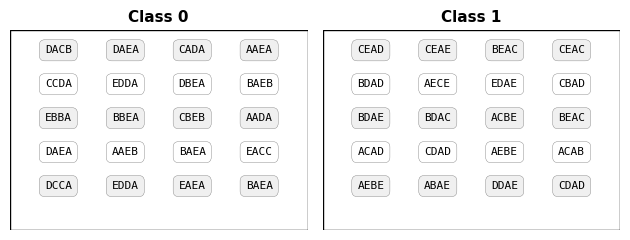

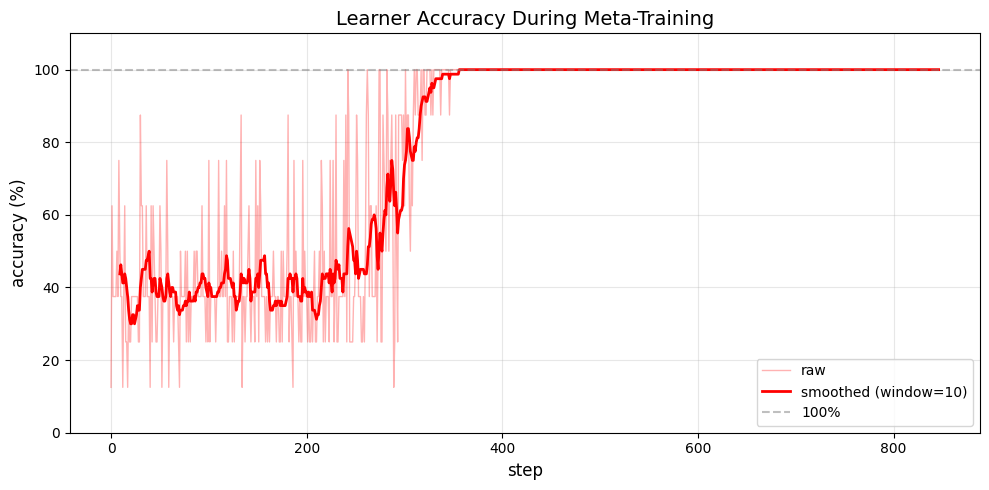

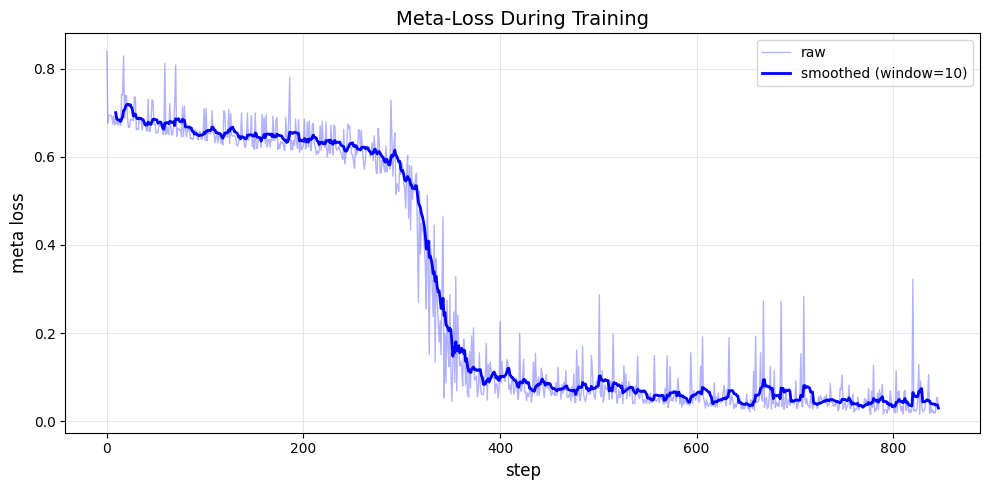

In [8]:
generator = Generator(num_classes=2, n_per_class=20, seq_len=4)

meta = MetaLearner(
    generator=generator,
    learner_class=RNN,
    meta_loss_fn=mlf.meta_loss_cross_entropy,
    regularization_fn=regularizer_combined,
    reg_parameter=1,
    num_classes=2,
    n_per_class=20,
    meta_lr=0.005,
    inner_lr=0.5, 
    inner_steps=10, 
    n_visualize=20,
    stop_after_consecutive_100=500
)

meta.train(steps=2000, visualize_every=0)
meta.plot_accuracy()
meta.plot_meta_loss()

In [12]:
num_rnns = 1000
num_classes=2
n_per_class=20
y = torch.arange(num_classes).repeat_interleave(n_per_class)
x = generator.forward().detach()

In [13]:
def permute_sequences(x, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    
    batch_size, seq_len, vocab_size = x.shape
    x_permuted = x.clone()
    
    for i in range(batch_size):
        perm = torch.randperm(seq_len)
        x_permuted[i] = x[i][perm]
    
    return x_permuted

In [14]:
results = {
    'original': [],
    'reversed': [],
    'permuted' : []
}

for rnn_idx in range(num_rnns):    
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    rnn = RNN(num_classes=num_classes)
    optimizer = torch.optim.SGD(rnn.parameters(), lr=0.5)

    for epoch in range(10):
        optimizer.zero_grad()
        logits = rnn(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    rnn.eval()
    with torch.no_grad():
        logits = rnn(x_test)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    results['original'].append(acc_original)

    x_reversed = torch.flip(x_test, dims=[1])

    with torch.no_grad():
        logits_rev = rnn(x_reversed)
        preds_rev = logits_rev.argmax(dim=1)
        acc_reversed = (preds_rev == y_test).float().mean().item() * 100
    results['reversed'].append(acc_reversed)

    x_permuted = permute_sequences(x_test, seed=rnn_idx)

    with torch.no_grad():
        logits_perm = rnn(x_permuted)
        preds_perm = logits_perm.argmax(dim=1)
        acc_permuted = (preds_perm == y_test).float().mean().item() * 100
    results['permuted'].append(acc_permuted)
    rnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])
mean_reversed = np.mean(results['reversed'])
std_reversed = np.std(results['reversed'])
mean_permuted = np.mean(results['permuted'])
std_permuted = np.std(results['permuted'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f}")
print(f"{'Reversed':<15} {mean_reversed:.2f} ± {std_reversed:.2f}")
print(f"{'Permuted':<15} {mean_permuted:.2f} ± {std_permuted:.2f}")

Data type       Accuracy (%)        
--------------------------------------------------
Original        100.00 ± 0.00
Reversed        0.00 ± 0.00
Permuted        50.12 ± 17.01


In [15]:
results = {
    'original': [],
    'reversed': [],
    'permuted' : []
}

for rnn_idx in range(num_rnns): 
    x_reversed = torch.flip(x, dims=[1])   
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x_reversed[train_idx]
    y_train = y[train_idx]
    x_test = x_reversed[test_idx]
    y_test = y[test_idx]
    
    rnn = RNN(num_classes=num_classes)
    optimizer = torch.optim.SGD(rnn.parameters(), lr=0.5)

    for epoch in range(10):
        optimizer.zero_grad()
        logits = rnn(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    rnn.eval()
    with torch.no_grad():
        logits = rnn(x_test)
        preds = logits.argmax(dim=1)
        acc_reversed = (preds == y_test).float().mean().item() * 100
    results['reversed'].append(acc_reversed)

    with torch.no_grad():
        logits_rev = rnn(x[test_idx])
        preds_rev = logits_rev.argmax(dim=1)
        acc_original = (preds_rev == y_test).float().mean().item() * 100
    results['original'].append(acc_original)

    x_permuted = permute_sequences(x_test, seed=rnn_idx)

    with torch.no_grad():
        logits_perm = rnn(x_permuted)
        preds_perm = logits_perm.argmax(dim=1)
        acc_permuted = (preds_perm == y_test).float().mean().item() * 100
    results['permuted'].append(acc_permuted)
    rnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])
mean_reversed = np.mean(results['reversed'])
std_reversed = np.std(results['reversed'])
mean_permuted = np.mean(results['permuted'])
std_permuted = np.std(results['permuted'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Reversed':<15} {mean_reversed:.2f} ± {std_reversed:.2f}")
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")
print(f"{'Permuted':<15} {mean_permuted:.2f} ± {std_permuted:.2f}")

Data type       Accuracy (%)        
--------------------------------------------------
Reversed        99.80 ± 3.57
Original        0.05 ± 0.79                
Permuted        49.39 ± 17.25


In [16]:
results = {
    'original': [],
    'reversed': [],
    'permuted' : []
}

for rnn_idx in range(num_rnns): 
    x_permuted = permute_sequences(x, seed=rnn_idx)   
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x_permuted[train_idx]
    y_train = y[train_idx]
    x_test = x_permuted[test_idx]
    y_test = y[test_idx]
    
    rnn = RNN(num_classes=num_classes)
    optimizer = torch.optim.SGD(rnn.parameters(), lr=0.5)

    for epoch in range(10):
        optimizer.zero_grad()
        logits = rnn(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    rnn.eval()
    with torch.no_grad():
        logits_perm = rnn(x_test)
        preds_perm = logits_perm.argmax(dim=1)
        acc_permuted = (preds_perm == y_test).float().mean().item() * 100
    results['permuted'].append(acc_permuted)

    x_reversed = torch.flip(x, dims=[1])

    with torch.no_grad():
        logits = rnn(x_reversed[test_idx])
        preds = logits.argmax(dim=1)
        acc_reversed = (preds == y_test).float().mean().item() * 100
    results['reversed'].append(acc_reversed)

    with torch.no_grad():
        logits_rev = rnn(x[test_idx])
        preds_rev = logits_rev.argmax(dim=1)
        acc_original = (preds_rev == y_test).float().mean().item() * 100
    results['original'].append(acc_original)
    rnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])
mean_reversed = np.mean(results['reversed'])
std_reversed = np.std(results['reversed'])
mean_permuted = np.mean(results['permuted'])
std_permuted = np.std(results['permuted'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Permuted':<15} {mean_permuted:.2f} ± {std_permuted:.2f}")
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")
print(f"{'Reversed':<15} {mean_reversed:.2f} ± {std_reversed:.2f}")

Data type       Accuracy (%)        
--------------------------------------------------
Permuted        38.42 ± 14.98
Original        38.88 ± 22.07                
Reversed        37.27 ± 19.59
